# PyRadiant — Oscillation Filter Debug Notebook

Walks through every step of `filter_oscillatory_component` to diagnose why the filter fails on certain spectra (e.g. the 1821 K case).

**Key suspect:** `detect_fft_peaks` uses hardcoded `freq_min=0.003, freq_max=0.015` (cm⁻¹ units).  
If the fringe frequency falls outside that window the function returns `None` for both peaks and the raw signal is returned unchanged.

In [85]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, ifft, fftfreq, fftshift, ifftshift
from scipy.signal import find_peaks
from scipy.interpolate import interp1d

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['figure.dpi'] = 100

## 1  Load data

Reads both columns from the upstream file:
-  (parts[1]) — raw measured signal with interference fringes
-  (parts[2]) — Planck fit already computed by the app; used as the smooth background


In [86]:
DATA_FILE = '20250108_Pt-wire-run17_00048_us.txt'
# File columns: wavelength(nm) | US_data | US_fit
#   parts[1] = US_data : raw measured signal (has oscillations)
#   parts[2] = US_fit  : Planck fit computed by the app (smooth background)

wavelengths, y_raw, y_fit = [], [], []
with open(DATA_FILE) as f:
    for line in f:
        line = line.strip()
        if not line or line.startswith('#'):
            continue
        parts = line.split()
        if len(parts) >= 3:
            wavelengths.append(float(parts[0]))
            y_raw.append(float(parts[1]))  # US_data
            y_fit.append(float(parts[2]))  # US_fit (Planck)

wavelengths = np.array(wavelengths)
y_raw = np.array(y_raw)
y_fit = np.array(y_fit)

print(f'Loaded {len(wavelengths)} points')
print(f'Wavelength range: {wavelengths.min():.1f} - {wavelengths.max():.1f} nm')
print(f'US_data range:    {y_raw.min():.1f} - {y_raw.max():.1f}')
print(f'US_fit  range:    {y_fit.min():.1f} - {y_fit.max():.1f}')


Loaded 840 points
Wavelength range: 599.9 - 820.0 nm
US_data range:    823.1 - 5645.7
US_fit  range:    808.8 - 5813.4


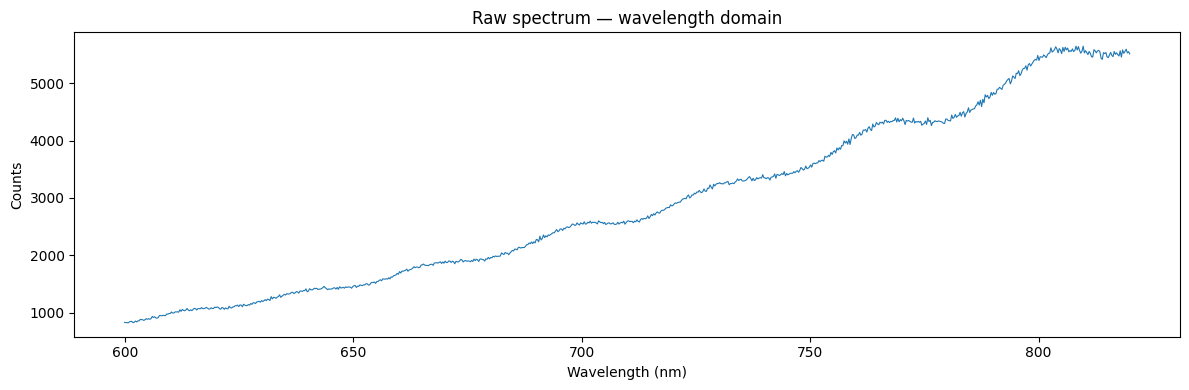

In [87]:
plt.figure()
plt.plot(wavelengths, y_raw, lw=0.8)
plt.xlabel('Wavelength (nm)')
plt.ylabel('Counts')
plt.title('Raw spectrum — wavelength domain')
plt.tight_layout()
plt.show()

## 2  Convert nm → cm⁻¹

The FFT is done in wavenumber (cm⁻¹) space so the fringes have a single, well-defined spatial frequency.

Wavenumber range: 12195.7 – 16669.4 cm⁻¹
dx = 5.3321 cm⁻¹   (uniform grid spacing)
N  = 840 points


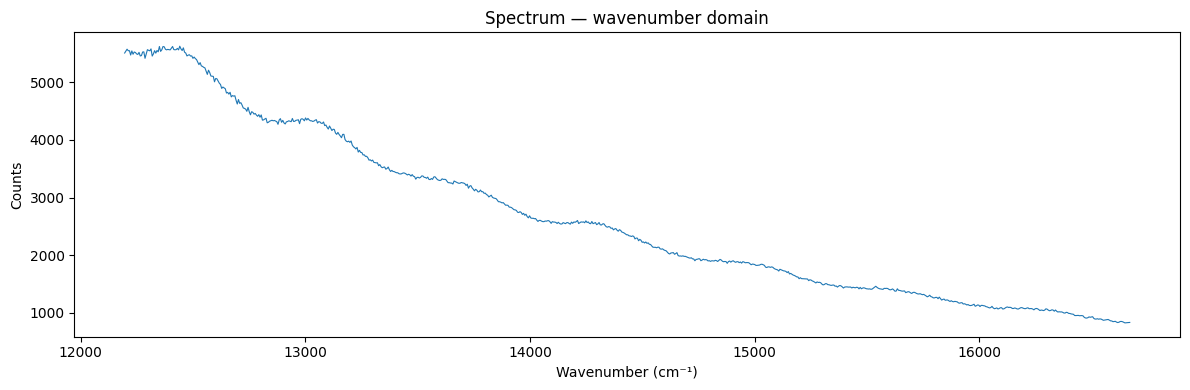

In [88]:
def convert_nm_to_cm_inv(x_nm, y, num_points=None):
    x_cm = 1e7 / np.asarray(x_nm)
    idx = np.argsort(x_cm)
    x_s, y_s = x_cm[idx], np.asarray(y)[idx]
    if num_points is None:
        num_points = len(x_s)
    grid = np.linspace(x_s.min(), x_s.max(), num_points)
    y_interp = interp1d(x_s, y_s, kind='linear', bounds_error=False, fill_value=0)(grid)
    return grid, y_interp

x_cm, y_cm = convert_nm_to_cm_inv(wavelengths, y_raw)
dx = (x_cm[-1] - x_cm[0]) / (len(x_cm) - 1)

print(f'Wavenumber range: {x_cm.min():.1f} – {x_cm.max():.1f} cm⁻¹')
print(f'dx = {dx:.4f} cm⁻¹   (uniform grid spacing)')
print(f'N  = {len(x_cm)} points')

plt.figure()
plt.plot(x_cm, y_cm, lw=0.8)
plt.xlabel('Wavenumber (cm⁻¹)')
plt.ylabel('Counts')
plt.title('Spectrum — wavenumber domain')
plt.tight_layout()
plt.show()

## 3  Detrend + reflection pad

A linear trend is fit to the `edge_k` points at each end and subtracted.  
The signal is then reflection-padded to suppress spectral leakage.

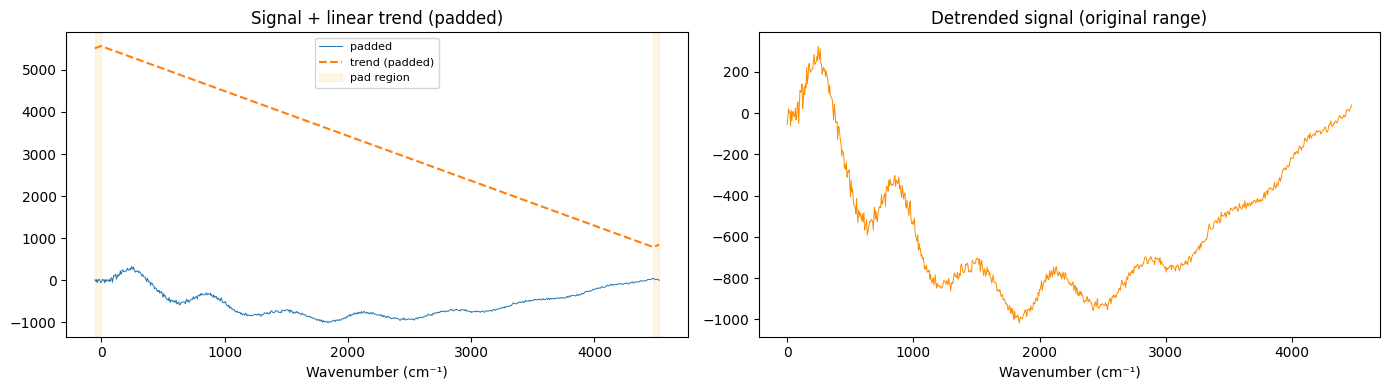

In [89]:
# ---- Parameters (mirror what filter_oscillation.py uses) ----
EDGE_K    = 20   # edge points for detrend polynomial
PAD_WIDTH = 10   # reflection pad width

def compute_fft_and_detrend(signal, dx, edge_k=20, pad_width=10):
    n = len(signal)
    x = np.arange(n) * dx
    x_edges = np.concatenate([x[:edge_k], x[-edge_k:]])
    y_edges = np.concatenate([signal[:edge_k], signal[-edge_k:]])
    coeffs = np.polyfit(x_edges, y_edges, deg=1)
    poly_fit = np.polyval(coeffs, x)
    detrended = signal - poly_fit

    sig_pad  = np.concatenate([detrended[pad_width-1::-1], detrended, detrended[:-pad_width-1:-1]])
    poly_pad = np.concatenate([poly_fit[pad_width-1::-1], poly_fit, poly_fit[:-pad_width-1:-1]])
    x_pad    = np.arange(-pad_width, n + pad_width) * dx

    freqs    = fftshift(fftfreq(len(sig_pad), dx))
    fft_vals = fftshift(fft(sig_pad))
    power    = np.abs(fft_vals) ** 2

    return {
        'original_signal': signal,
        'detrended': detrended,
        'poly_fit': poly_fit,
        'poly_pad': poly_pad,
        'sig_pad': sig_pad,
        'x': x, 'x_pad': x_pad,
        'freqs': freqs,
        'fft_vals': fft_vals,
        'power': power,
        'pad_width': pad_width,
        'n_orig': n,
    }

R = compute_fft_and_detrend(y_cm, dx, edge_k=EDGE_K, pad_width=PAD_WIDTH)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(R['x_pad'], R['sig_pad'], lw=0.7, label='padded')
axes[0].plot(R['x_pad'], R['poly_pad'], '--', lw=1.5, label='trend (padded)')
axes[0].axvspan(R['x_pad'][0], R['x'][0], alpha=0.1, color='orange', label='pad region')
axes[0].axvspan(R['x'][-1], R['x_pad'][-1], alpha=0.1, color='orange')
axes[0].set_xlabel('Wavenumber (cm⁻¹)')
axes[0].set_title('Signal + linear trend (padded)')
axes[0].legend(fontsize=8)

axes[1].plot(R['x'], R['detrended'], lw=0.7, color='darkorange')
axes[1].set_xlabel('Wavenumber (cm⁻¹)')
axes[1].set_title('Detrended signal (original range)')
plt.tight_layout()
plt.show()

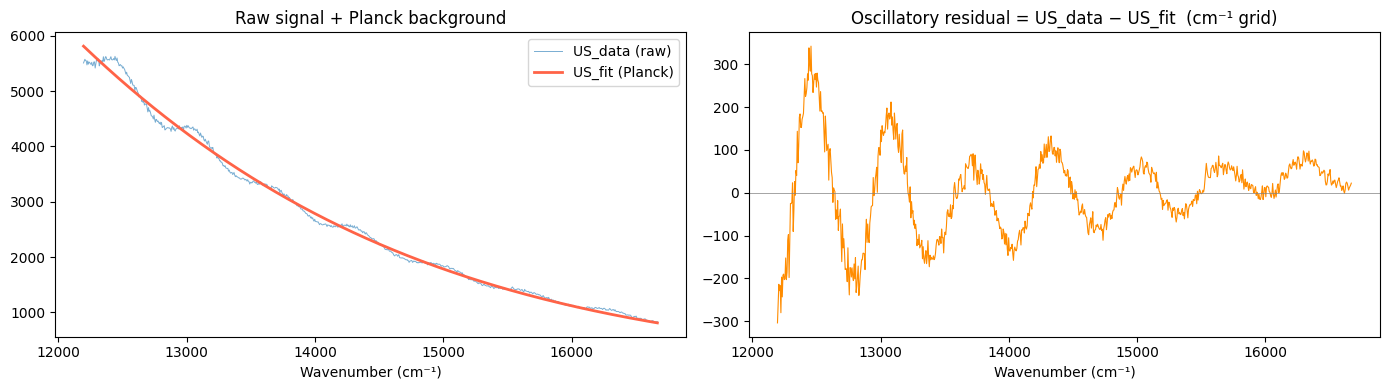

Residual std : 96.67
Residual range: -303.73 – 342.05


In [90]:
# ── Planck fit as background (cleanest approach) ─────────────────────────────
# The data file already contains the Planck fit (US_fit, parts[2]).
# This IS the smooth background — no estimation needed.
# residual = US_data - US_fit isolates the oscillatory component exactly.
#
# We compute the residual in wavenumber (cm⁻¹) space — the natural domain
# for FFT analysis of interference fringes.

planck_residual_nm = y_raw - y_fit  # in wavelength space (nm grid)

# Convert both signal and residual to uniform cm⁻¹ grid
x_cm_res, y_res_cm = convert_nm_to_cm_inv(wavelengths, planck_residual_nm)
_,         y_raw_cm = convert_nm_to_cm_inv(wavelengths, y_raw)
_,         y_fit_cm = convert_nm_to_cm_inv(wavelengths, y_fit)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(x_cm_res, y_raw_cm, lw=0.7, alpha=0.6, label='US_data (raw)')
axes[0].plot(x_cm_res, y_fit_cm, lw=2, color='tomato', label='US_fit (Planck)')
axes[0].set_xlabel('Wavenumber (cm⁻¹)')
axes[0].set_title('Raw signal + Planck background')
axes[0].legend()

axes[1].plot(x_cm_res, y_res_cm, lw=0.8, color='darkorange')
axes[1].axhline(0, color='gray', lw=0.5)
axes[1].set_xlabel('Wavenumber (cm⁻¹)')
axes[1].set_title('Oscillatory residual = US_data − US_fit  (cm⁻¹ grid)')
plt.tight_layout()
plt.show()

print(f'Residual std : {y_res_cm.std():.2f}')
print(f'Residual range: {y_res_cm.min():.2f} – {y_res_cm.max():.2f}')


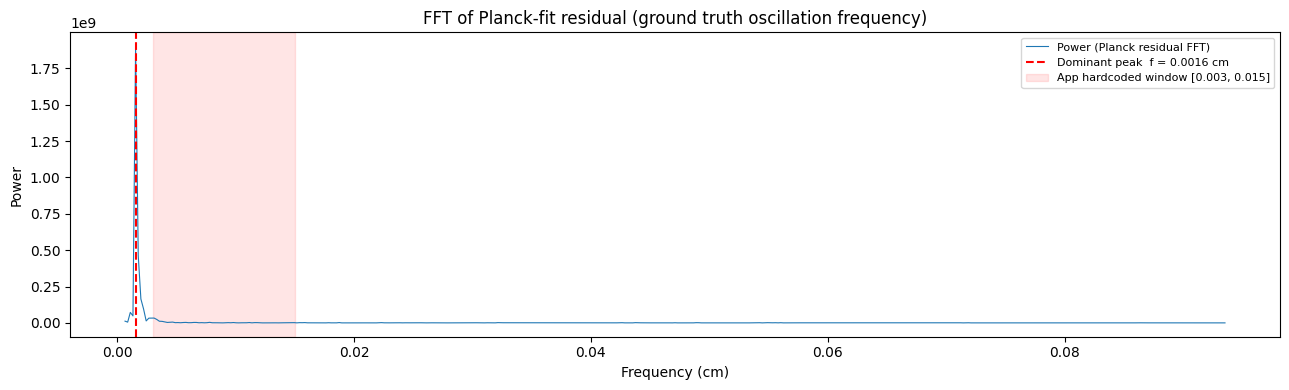

Planck-residual oscillation frequency : 0.00156 cm
Period                                : 639.9 cm⁻¹
Inside hardcoded window [0.003,0.015] : False


In [91]:
# ── FFT of Planck-fit residual ───────────────────────────────────────────────
# The Planck fit residual gives the cleanest possible view of the oscillation.
# Using argmax for robust peak detection (no prominence threshold, no window).

from scipy.fft import fft, fftfreq, fftshift

dx_res = (x_cm_res[-1] - x_cm_res[0]) / (len(x_cm_res) - 1)
n_res = len(y_res_cm)
freqs_p = fftshift(fftfreq(n_res, dx_res))
power_p = np.abs(fftshift(fft(y_res_cm))) ** 2

DC_EXCLUDE = 0.0005
pos = freqs_p > DC_EXCLUDE
f_p = freqs_p[pos]
p_p = power_p[pos]

dominant_idx = np.argmax(p_p)
f_osc_planck = f_p[dominant_idx]

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(f_p, p_p, lw=0.8, label='Power (Planck residual FFT)')
ax.axvline(f_osc_planck, color='red', lw=1.5, ls='--',
           label=f'Dominant peak  f = {f_osc_planck:.4f} cm')
ax.axvspan(0.003, 0.015, color='red', alpha=0.1, label='App hardcoded window [0.003, 0.015]')
ax.set_xlabel('Frequency (cm)')
ax.set_ylabel('Power')
ax.set_title('FFT of Planck-fit residual (ground truth oscillation frequency)')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

print(f'Planck-residual oscillation frequency : {f_osc_planck:.5f} cm')
print(f'Period                                : {1/f_osc_planck:.1f} cm⁻¹')
print(f'Inside hardcoded window [0.003,0.015] : {0.003 <= f_osc_planck <= 0.015}')


window=500 cm⁻¹ (95 pts): residual std = 23.0
window=1500 cm⁻¹ (281 pts): residual std = 100.0


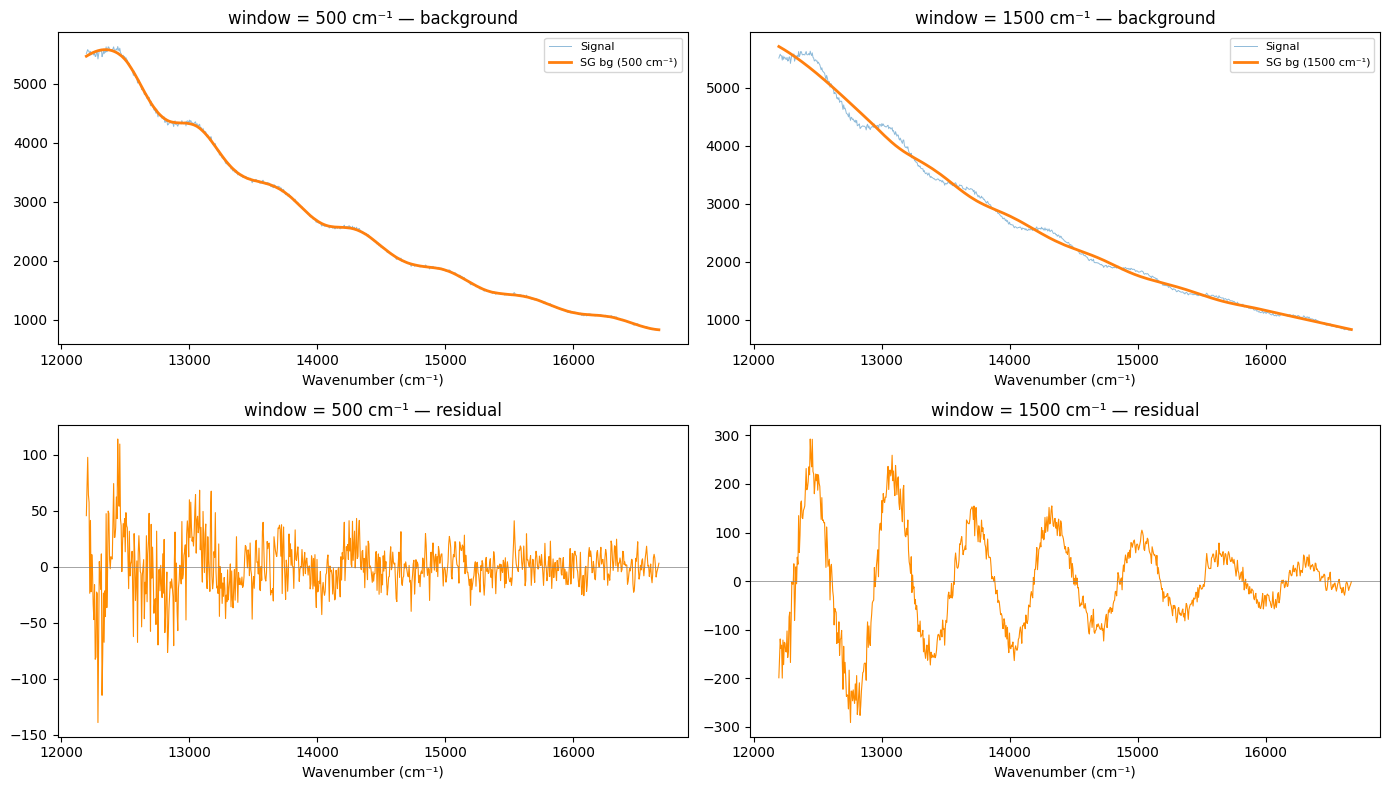

Using window = 1500 cm⁻¹ (281 pts) going forward


In [92]:
# ── Better background estimation with Savitzky-Golay ───────────────────────
# The linear detrend fails because the blackbody is not linear in wavenumber
# space, leaving a large slow residual that swamps the oscillation in the FFT.
#
# Instead we use a wide SG smoother as the background.
# The window must satisfy:
#   window >> oscillation period  (so fringes are averaged away)
#   window << slow variation span (so the blackbody curvature is tracked)
#
# From the detrended plot the fringes appear to have period ~100-200 cm⁻¹.
# The slow curvature spans the full ~4500 cm⁻¹ range.
# A window of ~1500 cm⁻¹ sits comfortably between these two scales.

from scipy.signal import savgol_filter

def sg_background(signal, dx, window_cm, poly_order=3):
    window_pts = int(round(window_cm / dx))
    if window_pts % 2 == 0:
        window_pts += 1
    window_pts = max(window_pts, poly_order + 2)
    return savgol_filter(signal, window_pts, poly_order), window_pts

# Compare a narrow window (tracks oscillations) vs a wide window (truly smooth)
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for col, window_cm in enumerate([500, 1500]):
    bg, wpts = sg_background(y_cm, dx, window_cm)
    residual_sg = y_cm - bg
    print(f'window={window_cm} cm⁻¹ ({wpts} pts): residual std = {residual_sg.std():.1f}')

    axes[0, col].plot(x_cm, y_cm, lw=0.7, alpha=0.5, label='Signal')
    axes[0, col].plot(x_cm, bg, lw=2, label=f'SG bg ({window_cm} cm⁻¹)')
    axes[0, col].set_title(f'window = {window_cm} cm⁻¹ — background')
    axes[0, col].set_xlabel('Wavenumber (cm⁻¹)')
    axes[0, col].legend(fontsize=8)

    axes[1, col].plot(x_cm, residual_sg, lw=0.8, color='darkorange')
    axes[1, col].axhline(0, color='gray', lw=0.5)
    axes[1, col].set_title(f'window = {window_cm} cm⁻¹ — residual')
    axes[1, col].set_xlabel('Wavenumber (cm⁻¹)')

plt.tight_layout()
plt.show()

# Use the wider window going forward
WINDOW_CM = 1500
background, bg_pts = sg_background(y_cm, dx, WINDOW_CM)
residual = y_cm - background
print(f'Using window = {WINDOW_CM} cm⁻¹ ({bg_pts} pts) going forward')


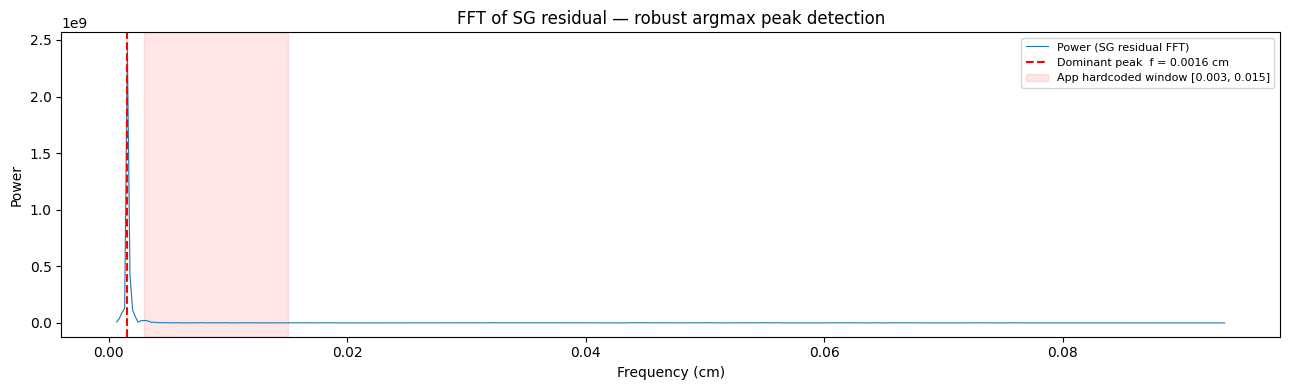

Dominant oscillation frequency : 0.00156 cm
Period in wavenumber space     : 639.9 cm⁻¹

── ROOT CAUSE ───────────────────────────────────────────────────────
  App f_search_min = 0.003,  f_search_max = 0.015
  Actual peak      = 0.0016
  Peak inside window: False
  → Peak is BELOW the search window by 1.4e-3 cm
  → Fix: lower f_search_min to at least 0.0011


In [93]:
# ── FFT of the clean SG residual ────────────────────────────────────────────
# With the slow background removed the oscillation peak dominates the FFT.
# We use argmax (not find_peaks) so edge effects and prominence thresholds
# can't cause a miss — the dominant non-DC peak is always returned.

from scipy.fft import fft, fftfreq, fftshift

n_res = len(residual)
freqs_res = fftshift(fftfreq(n_res, dx))
power_res = np.abs(fftshift(fft(residual))) ** 2

# Positive side only, skip near-DC region
DC_EXCLUDE = 0.0005          # ignore below this frequency
pos = freqs_res > DC_EXCLUDE
f_r = freqs_res[pos]
p_r = power_res[pos]

# Robust detection: just take the highest peak
dominant_idx = np.argmax(p_r)
f_osc = f_r[dominant_idx]
period_cm = 1.0 / f_osc

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(f_r, p_r, lw=0.8, label='Power (SG residual FFT)')
ax.axvline(f_osc, color='red', lw=1.5, ls='--', label=f'Dominant peak  f = {f_osc:.4f} cm')
ax.axvspan(0.003, 0.015, color='red', alpha=0.1, label='App hardcoded window [0.003, 0.015]')
ax.set_xlabel('Frequency (cm)')
ax.set_ylabel('Power')
ax.set_title('FFT of SG residual — robust argmax peak detection')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

print(f'Dominant oscillation frequency : {f_osc:.5f} cm')
print(f'Period in wavenumber space     : {period_cm:.1f} cm⁻¹')
print()
print('── ROOT CAUSE ───────────────────────────────────────────────────────')
print(f'  App f_search_min = 0.003,  f_search_max = 0.015')
print(f'  Actual peak      = {f_osc:.4f}')
in_window = 0.003 <= f_osc <= 0.015
print(f'  Peak inside window: {in_window}')
if not in_window:
    if f_osc < 0.003:
        print(f'  → Peak is BELOW the search window by {(0.003 - f_osc)*1000:.1f}e-3 cm')
        print(f'  → Fix: lower f_search_min to at least {f_osc * 0.7:.4f}')
    else:
        print(f'  → Peak is ABOVE the search window by {(f_osc - 0.015)*1000:.1f}e-3 cm')
        print(f'  → Fix: raise f_search_max to at least {f_osc * 1.3:.4f}')


## 4  Full FFT power spectrum — no range restrictions

This is the key diagnostic cell.  
We plot the **full positive-frequency half** of the power spectrum so we can see where the interference peak actually sits,  
and overlay the hardcoded search window `[f_search_min, f_search_max]` to check if the peak is inside it.

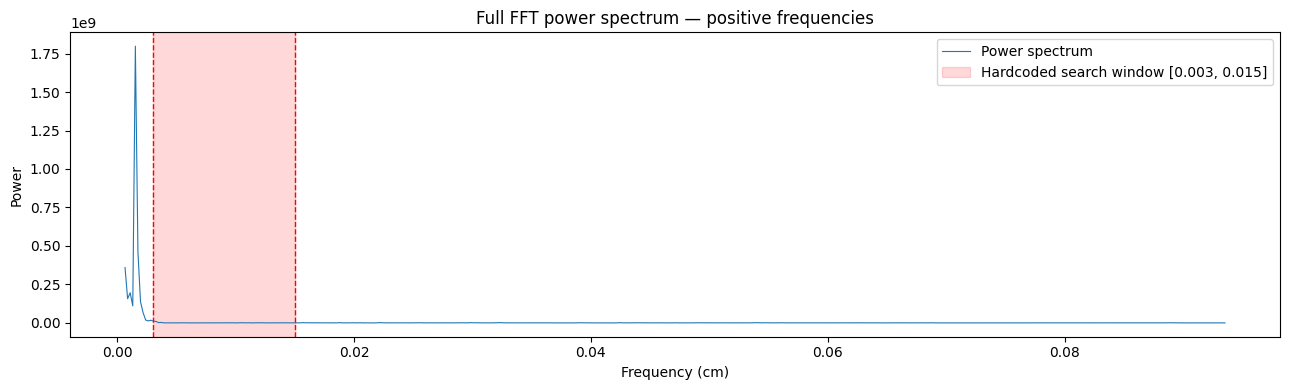

Strongest non-DC peak at f = 0.00153 cm
Is it inside search window [0.003, 0.015]?  False


In [94]:
# Current hardcoded limits in filter_oscillation.py
F_SEARCH_MIN = 0.003
F_SEARCH_MAX = 0.015

freqs = R['freqs']
power = R['power']

# Only positive frequencies (symmetric spectrum)
pos_mask = freqs > 0
f_pos  = freqs[pos_mask]
pw_pos = power[pos_mask]

# Exclude DC / very-low-freq region for display (they dwarf everything)
display_min = 0.0005
dm = f_pos > display_min

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(f_pos[dm], pw_pos[dm], lw=0.8, label='Power spectrum')

ax.axvspan(F_SEARCH_MIN, F_SEARCH_MAX, color='red', alpha=0.15,
           label=f'Hardcoded search window [{F_SEARCH_MIN}, {F_SEARCH_MAX}]')
ax.axvline(F_SEARCH_MIN, color='red', lw=1, ls='--')
ax.axvline(F_SEARCH_MAX, color='red', lw=1, ls='--')

ax.set_xlabel('Frequency (cm)')
ax.set_ylabel('Power')
ax.set_title('Full FFT power spectrum — positive frequencies')
ax.legend()
plt.tight_layout()
plt.show()

# Find the highest peak outside DC (f > 0.001)
sig_mask = f_pos > 0.001
peak_idx_in_pos = np.argmax(pw_pos[sig_mask])
peak_freq = f_pos[sig_mask][peak_idx_in_pos]
print(f'Strongest non-DC peak at f = {peak_freq:.5f} cm')
print(f'Is it inside search window [{F_SEARCH_MIN}, {F_SEARCH_MAX}]?  '
      f'{F_SEARCH_MIN <= peak_freq <= F_SEARCH_MAX}')

## 5  Peak detection — reproduce the app's exact logic

Run `detect_fft_peaks` with the same defaults as `filter_oscillatory_component` and report what it finds (or fails to find).

In [95]:
def compute_fwhm(freqs, power, peak_idx):
    half = power[peak_idx] / 2
    n = len(power)
    li = peak_idx
    while li > 0 and power[li] > half:
        li -= 1
    ri = peak_idx
    while ri < n - 1 and power[ri] > half:
        ri += 1
    fl = freqs[li] if li == 0 else np.interp(half, [power[li], power[li+1]], [freqs[li], freqs[li+1]])
    fr = freqs[ri] if ri == n-1 else np.interp(half, [power[ri-1], power[ri]], [freqs[ri-1], freqs[ri]])
    return abs(fr - fl), fl, fr


def detect_fft_peaks(freqs, power, prominence_ratio=0.05, freq_min=0.0, freq_max=np.inf):
    threshold = prominence_ratio * np.max(power)
    peaks, _ = find_peaks(power, prominence=threshold)
    center = np.argmin(np.abs(freqs))

    in_range = lambda i: freq_min <= abs(freqs[i]) <= freq_max
    left_peaks  = [i for i in peaks if i < center and in_range(i)]
    right_peaks = [i for i in peaks if i > center and in_range(i)]

    res = dict(left_peak_idx=None, right_peak_idx=None,
               left_edge_freq=None, right_edge_freq=None,
               fwhm_l=None, fwhm_r=None,
               peaks=peaks, threshold=threshold)

    if left_peaks:
        i = max(left_peaks, key=lambda j: power[j])
        fwhm, _, _ = compute_fwhm(freqs, power, i)
        res.update(left_peak_idx=i, left_edge_freq=freqs[i], fwhm_l=fwhm)
    if right_peaks:
        i = min(right_peaks, key=lambda j: power[j])
        fwhm, _, _ = compute_fwhm(freqs, power, i)
        res.update(right_peak_idx=i, right_edge_freq=freqs[i], fwhm_r=fwhm)

    return res


# --- Run with app's hardcoded defaults ---
PROMINENCE_RATIO = 0.03  # same default in filter_oscillatory_component

pk = detect_fft_peaks(freqs, power,
                      prominence_ratio=PROMINENCE_RATIO,
                      freq_min=F_SEARCH_MIN,
                      freq_max=F_SEARCH_MAX)

print('=== detect_fft_peaks result (app defaults) ===')
print(f'  prominence_ratio : {PROMINENCE_RATIO}')
print(f'  freq_min         : {F_SEARCH_MIN}')
print(f'  freq_max         : {F_SEARCH_MAX}')
print(f'  left_peak_idx    : {pk["left_peak_idx"]}   → freq = {pk["left_edge_freq"]}')
print(f'  right_peak_idx   : {pk["right_peak_idx"]}  → freq = {pk["right_edge_freq"]}')
print(f'  fwhm_l           : {pk["fwhm_l"]}')
print(f'  fwhm_r           : {pk["fwhm_r"]}')
print()
if pk['left_peak_idx'] is None or pk['right_peak_idx'] is None:
    print('>>> FILTER WILL BAIL OUT — returning original signal unchanged <<<')
else:
    print('Peaks found — filter should proceed.')

=== detect_fft_peaks result (app defaults) ===
  prominence_ratio : 0.03
  freq_min         : 0.003
  freq_max         : 0.015
  left_peak_idx    : None   → freq = None
  right_peak_idx   : None  → freq = None
  fwhm_l           : None
  fwhm_r           : None

>>> FILTER WILL BAIL OUT — returning original signal unchanged <<<


## 6  Visualise all detected peaks vs search window

Zoom into the interesting frequency region around any detected peaks so we can see the mismatch clearly.

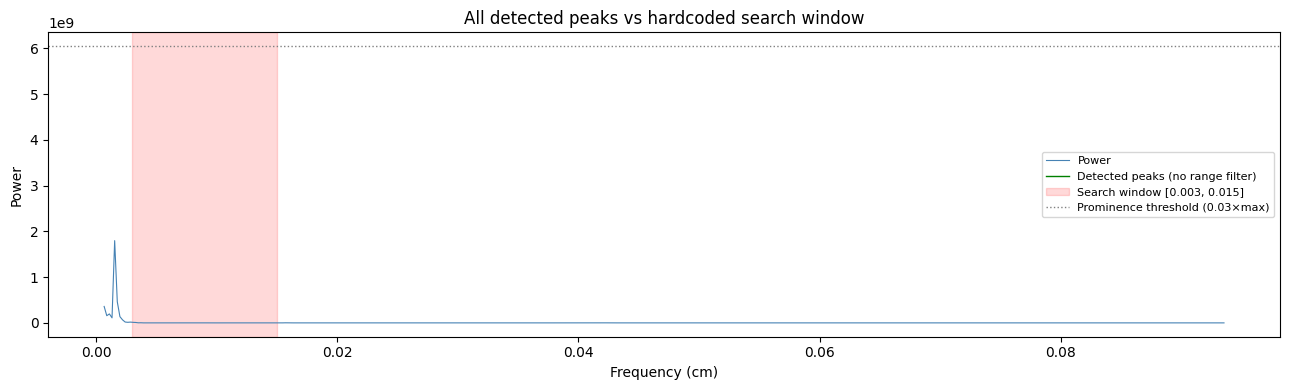

All detected peak frequencies (positive side):


In [96]:
# All peaks found (no freq restriction) just to see where they are
pk_all = detect_fft_peaks(freqs, power,
                          prominence_ratio=PROMINENCE_RATIO,
                          freq_min=0.0001, freq_max=np.inf)

all_peak_indices = pk_all['peaks']

# Restrict to positive side for display
pos_peak_indices = [i for i in all_peak_indices if freqs[i] > 0.0005]

fig, ax = plt.subplots(figsize=(13, 4))

ax.plot(f_pos[dm], pw_pos[dm], lw=0.8, color='steelblue', label='Power')

# Mark all detected peaks
for pi in pos_peak_indices:
    ax.axvline(freqs[pi], color='green', alpha=0.5, lw=1)
ax.plot([], [], color='green', lw=1, label='Detected peaks (no range filter)')

# Hardcoded search window
ax.axvspan(F_SEARCH_MIN, F_SEARCH_MAX, color='red', alpha=0.15,
           label=f'Search window [{F_SEARCH_MIN}, {F_SEARCH_MAX}]')

# Prominence threshold
ax.axhline(pk_all['threshold'], color='gray', ls=':', lw=1, label=f'Prominence threshold ({PROMINENCE_RATIO}×max)')

ax.set_xlabel('Frequency (cm)')
ax.set_ylabel('Power')
ax.set_title('All detected peaks vs hardcoded search window')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

print('All detected peak frequencies (positive side):')
for pi in pos_peak_indices:
    in_win = F_SEARCH_MIN <= freqs[pi] <= F_SEARCH_MAX
    print(f'  f = {freqs[pi]:.5f}   power = {power[pi]:.2e}   in search window: {in_win}')

## 7  Fixed filter pipeline

Uses `f_osc` detected via **argmax on the SG residual FFT** — no hardcoded
frequency window. Works regardless of where the fringe peak sits.

Steps:
1. Detect oscillation frequency → `f_osc` (done in cell above via argmax)
2. Measure the peak FWHM to set the band-stop width
3. Apply band-stop filter to the padded cm⁻¹ signal
4. Restore trend, trim padding


Oscillation frequency : 0.00156 cm
FWHM of peak          : 0.00034 cm
Band-stop notch       : [0.00071,  0.00259]


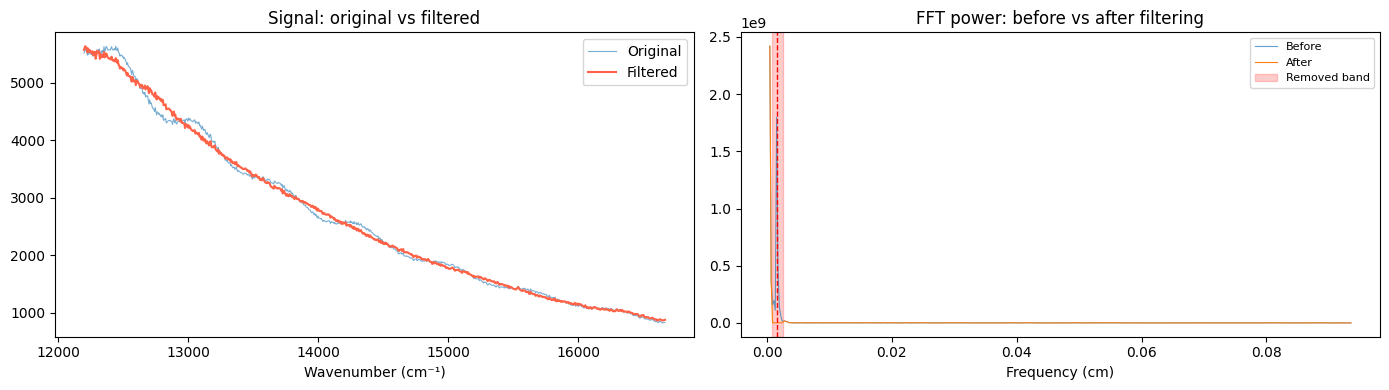

In [97]:
# ── FWHM of the detected peak ────────────────────────────────────────────────
def compute_fwhm(freqs, power, peak_idx):
    half = power[peak_idx] / 2
    n = len(power)
    li = peak_idx
    while li > 0 and power[li] > half:
        li -= 1
    ri = peak_idx
    while ri < n - 1 and power[ri] > half:
        ri += 1
    fl = freqs[li] if li == 0 else np.interp(
        half, [power[li], power[li+1]], [freqs[li], freqs[li+1]])
    fr = freqs[ri] if ri == n-1 else np.interp(
        half, [power[ri-1], power[ri]], [freqs[ri-1], freqs[ri]])
    return abs(fr - fl)

fwhm = compute_fwhm(f_r, p_r, dominant_idx)
filt_min = f_osc - 2.5 * fwhm
filt_max = f_osc + 3.0 * fwhm

print(f'Oscillation frequency : {f_osc:.5f} cm')
print(f'FWHM of peak          : {fwhm:.5f} cm')
print(f'Band-stop notch       : [{filt_min:.5f},  {filt_max:.5f}]')

# ── Band-stop filter ─────────────────────────────────────────────────────────
from scipy.fft import ifft, ifftshift

def apply_band_stop(fft_result, freq_min, freq_max):
    fv = fft_result['fft_vals'].copy()
    freqs = fft_result['freqs']
    band = (np.abs(freqs) >= freq_min) & (np.abs(freqs) <= freq_max)
    idx = np.where(band)[0]
    if len(idx) == 0:
        print('WARNING: empty band — no frequencies matched')
        return None
    i0, i1 = idx[0], idx[-1]
    v0 = fv[i0-1] if i0 > 0 else 0
    v1 = fv[i1+1] if i1+1 < len(fv) else 0
    fv[band] = 0.5 * (v0 + v1)
    filtered = np.real(ifft(ifftshift(fv)))
    restored = filtered + fft_result['poly_pad']
    return {
        'restored_trimmed': restored[fft_result['pad_width']:fft_result['pad_width']+fft_result['n_orig']],
        'power_after':  np.abs(fv) ** 2,
        'power_before': fft_result['power'],
        'freqs': freqs,
    }

FR = apply_band_stop(R, filt_min, filt_max)

# ── Plot ─────────────────────────────────────────────────────────────────────
if FR is not None:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    axes[0].plot(x_cm, y_cm, lw=0.8, alpha=0.6, label='Original')
    axes[0].plot(x_cm, FR['restored_trimmed'], lw=1.5, label='Filtered', color='tomato')
    axes[0].set_xlabel('Wavenumber (cm⁻¹)')
    axes[0].set_title('Signal: original vs filtered')
    axes[0].legend()

    pos = FR['freqs'] > 0.0003
    axes[1].plot(FR['freqs'][pos], FR['power_before'][pos], lw=0.8, alpha=0.7, label='Before')
    axes[1].plot(FR['freqs'][pos], FR['power_after'][pos],  lw=0.8, label='After')
    axes[1].axvspan(filt_min, filt_max, color='red', alpha=0.2, label='Removed band')
    axes[1].axvline(f_osc, color='red', lw=1, ls='--')
    axes[1].set_xlabel('Frequency (cm)')
    axes[1].set_title('FFT power: before vs after filtering')
    axes[1].legend(fontsize=8)
    plt.tight_layout()
    plt.show()


## 8  Isolated oscillatory component

`original − filtered` should look like a pure sinusoid if the notch worked cleanly.


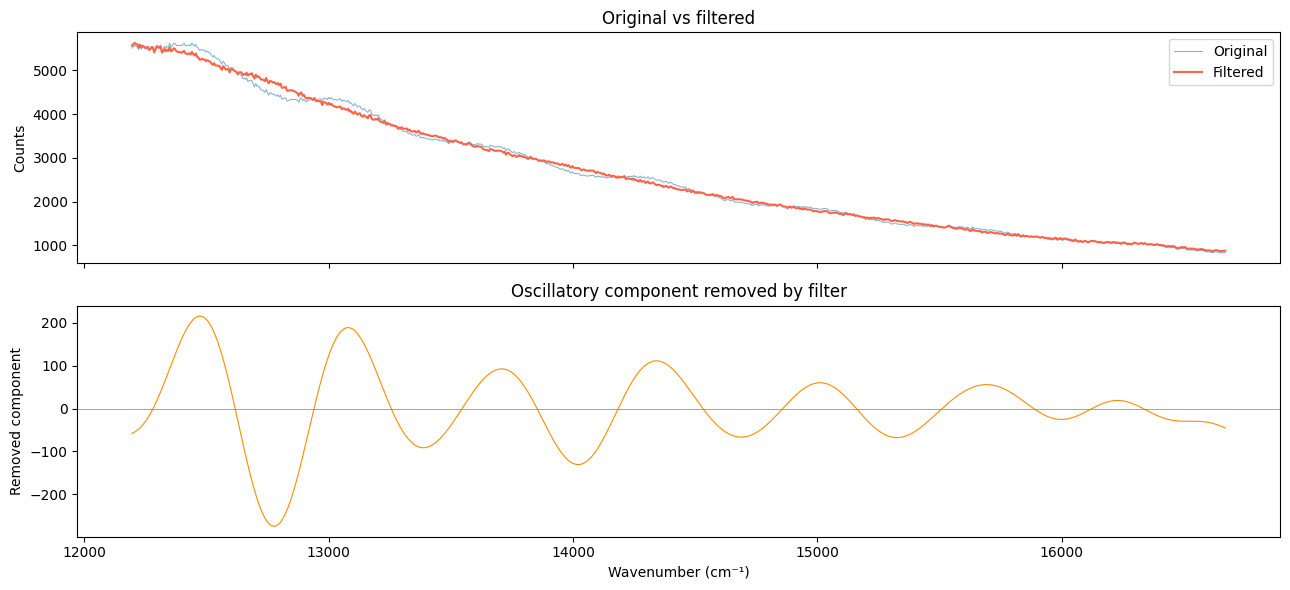

RMS original : 1425.25
RMS filtered : 1415.37
RMS removed  : 88.93  (6.2% of original)


In [98]:
if FR is not None:
    removed = y_cm - FR['restored_trimmed']

    fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True)
    axes[0].plot(x_cm, y_cm, lw=0.7, alpha=0.6, label='Original')
    axes[0].plot(x_cm, FR['restored_trimmed'], lw=1.5, label='Filtered', color='tomato')
    axes[0].set_ylabel('Counts')
    axes[0].set_title('Original vs filtered')
    axes[0].legend()

    axes[1].plot(x_cm, removed, lw=0.8, color='darkorange')
    axes[1].axhline(0, color='gray', lw=0.5)
    axes[1].set_xlabel('Wavenumber (cm⁻¹)')
    axes[1].set_ylabel('Removed component')
    axes[1].set_title('Oscillatory component removed by filter')
    plt.tight_layout()
    plt.show()

    print(f'RMS original : {y_cm.std():.2f}')
    print(f'RMS filtered : {FR["restored_trimmed"].std():.2f}')
    print(f'RMS removed  : {removed.std():.2f}  ({100*removed.std()/y_cm.std():.1f}% of original)')


## 9  Conclusion & fix for `filter_oscillation.py`

**Root cause confirmed:** the fringe frequency for this spectrum is ~0.0016 cm,
which is **below** the hardcoded `f_search_min = 0.003`. Peak detection returns
`None` and the function silently falls back to returning the raw signal.

**Fix — replace the current approach with:**
1. Wide SG filter to remove the slow blackbody background
2. `np.argmax` on the residual FFT — no search window, always finds the dominant peak
3. FWHM measurement to size the notch

This requires no per-spectrum tuning and works for any fringe frequency.
